In [29]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage as ndi
import skimage as ski
from PIL import Image
import cv2
from skimage.filters import sato

In [30]:
IMAGE_ID = 'S1585-2_a'
ROI_X = 4820
ROI_Y = 1710
ROI_W = 128
ROI_H = 256


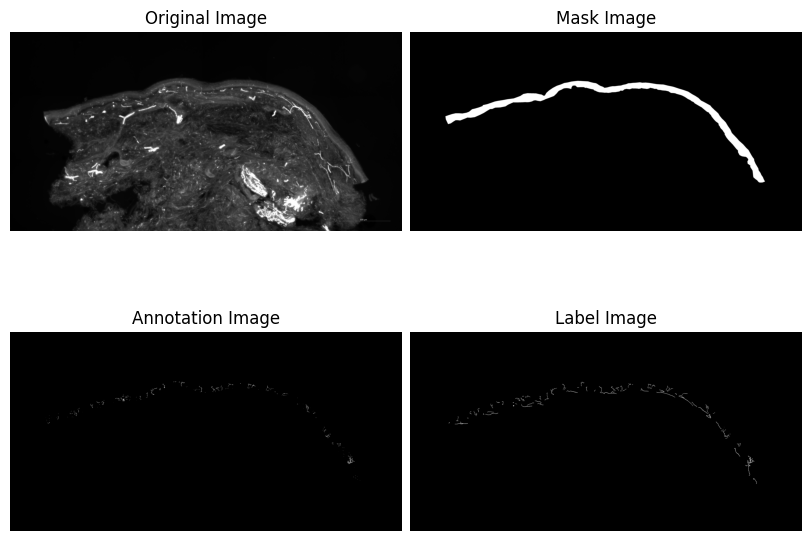

In [31]:
base_path = f"../data/{IMAGE_ID}/"

orig_img = cv2.imread(f"{base_path}/image.png")[:, :, 1]
mask_img = cv2.imread(f"{base_path}/mask.png", cv2.IMREAD_GRAYSCALE)
annotation_img = cv2.imread(f"{base_path}/annotation.png", cv2.IMREAD_GRAYSCALE)
label_img = cv2.imread(f"{base_path}/label.png", cv2.IMREAD_GRAYSCALE)

_, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 6), constrained_layout=True)
axes[0, 0].imshow(orig_img, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].set_axis_off()
axes[0, 1].imshow(mask_img, cmap='gray')
axes[0, 1].set_title('Mask Image')
axes[0, 1].set_axis_off()
axes[1, 0].imshow(annotation_img, cmap='gray')
axes[1, 0].set_title('Annotation Image')
axes[1, 0].set_axis_off()
axes[1, 1].imshow(label_img, cmap='gray')
axes[1, 1].set_title('Label Image')
axes[1, 1].set_axis_off()
plt.show()

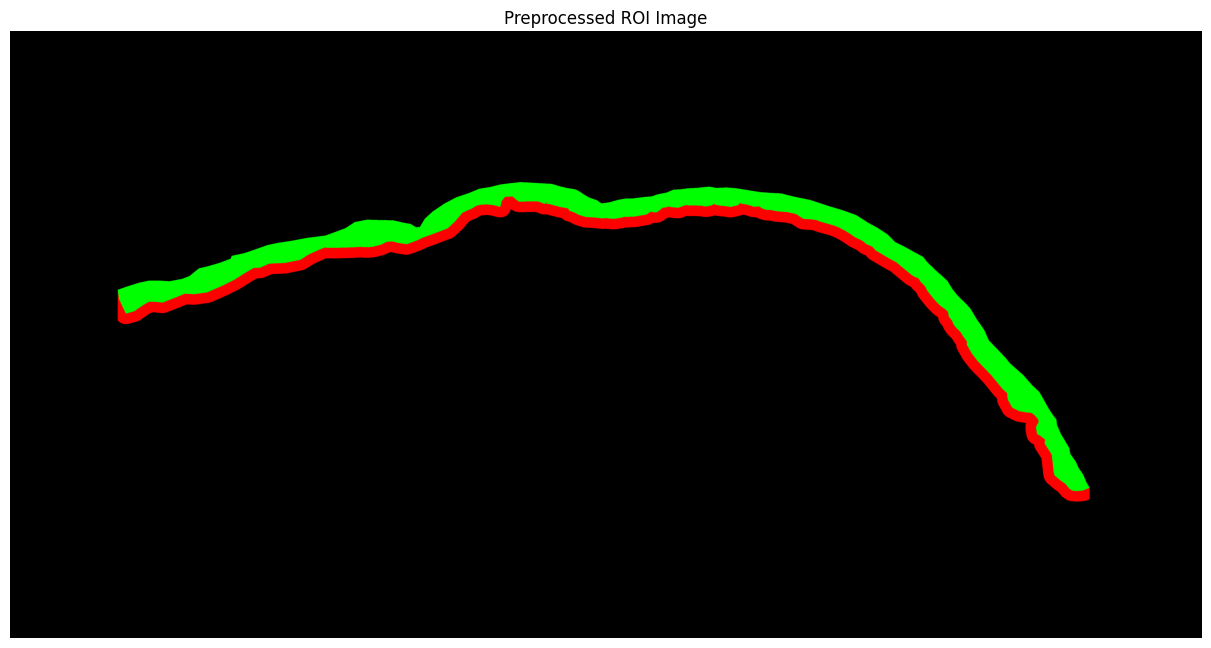

In [32]:
import cv2

mask_uint8 = mask_img.astype(np.uint8) * 255

offset_px = 100
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, offset_px * 6))
anchor = (0, offset_px*6 - 1)
dilated = cv2.dilate(mask_uint8, kernel, anchor=anchor, iterations=1)

dermis_available_mask =  dilated - mask_uint8

dermis_mask = cv2.bitwise_and(dermis_available_mask , cv2.dilate(mask_uint8, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (offset_px,offset_px)), iterations=1))
roi_mask = cv2.bitwise_or(dermis_mask.astype(np.uint8), mask_uint8.astype(np.uint8))

viz_mask = cv2.cvtColor(mask_uint8.copy(), cv2.COLOR_GRAY2BGR)
viz_mask[mask_uint8 > 0] = [0, 255, 0]
viz_mask[dermis_mask > 0] = [255, 0, 0]

_, axes = plt.subplots(nrows=1, ncols=1, figsize=(12,8), constrained_layout=True)
axes.imshow(viz_mask)
axes.set_title('Preprocessed ROI Image')
axes.set_axis_off()
plt.show()

ROI height: 1508, width: 4591, y_start: 714, x_start: 509


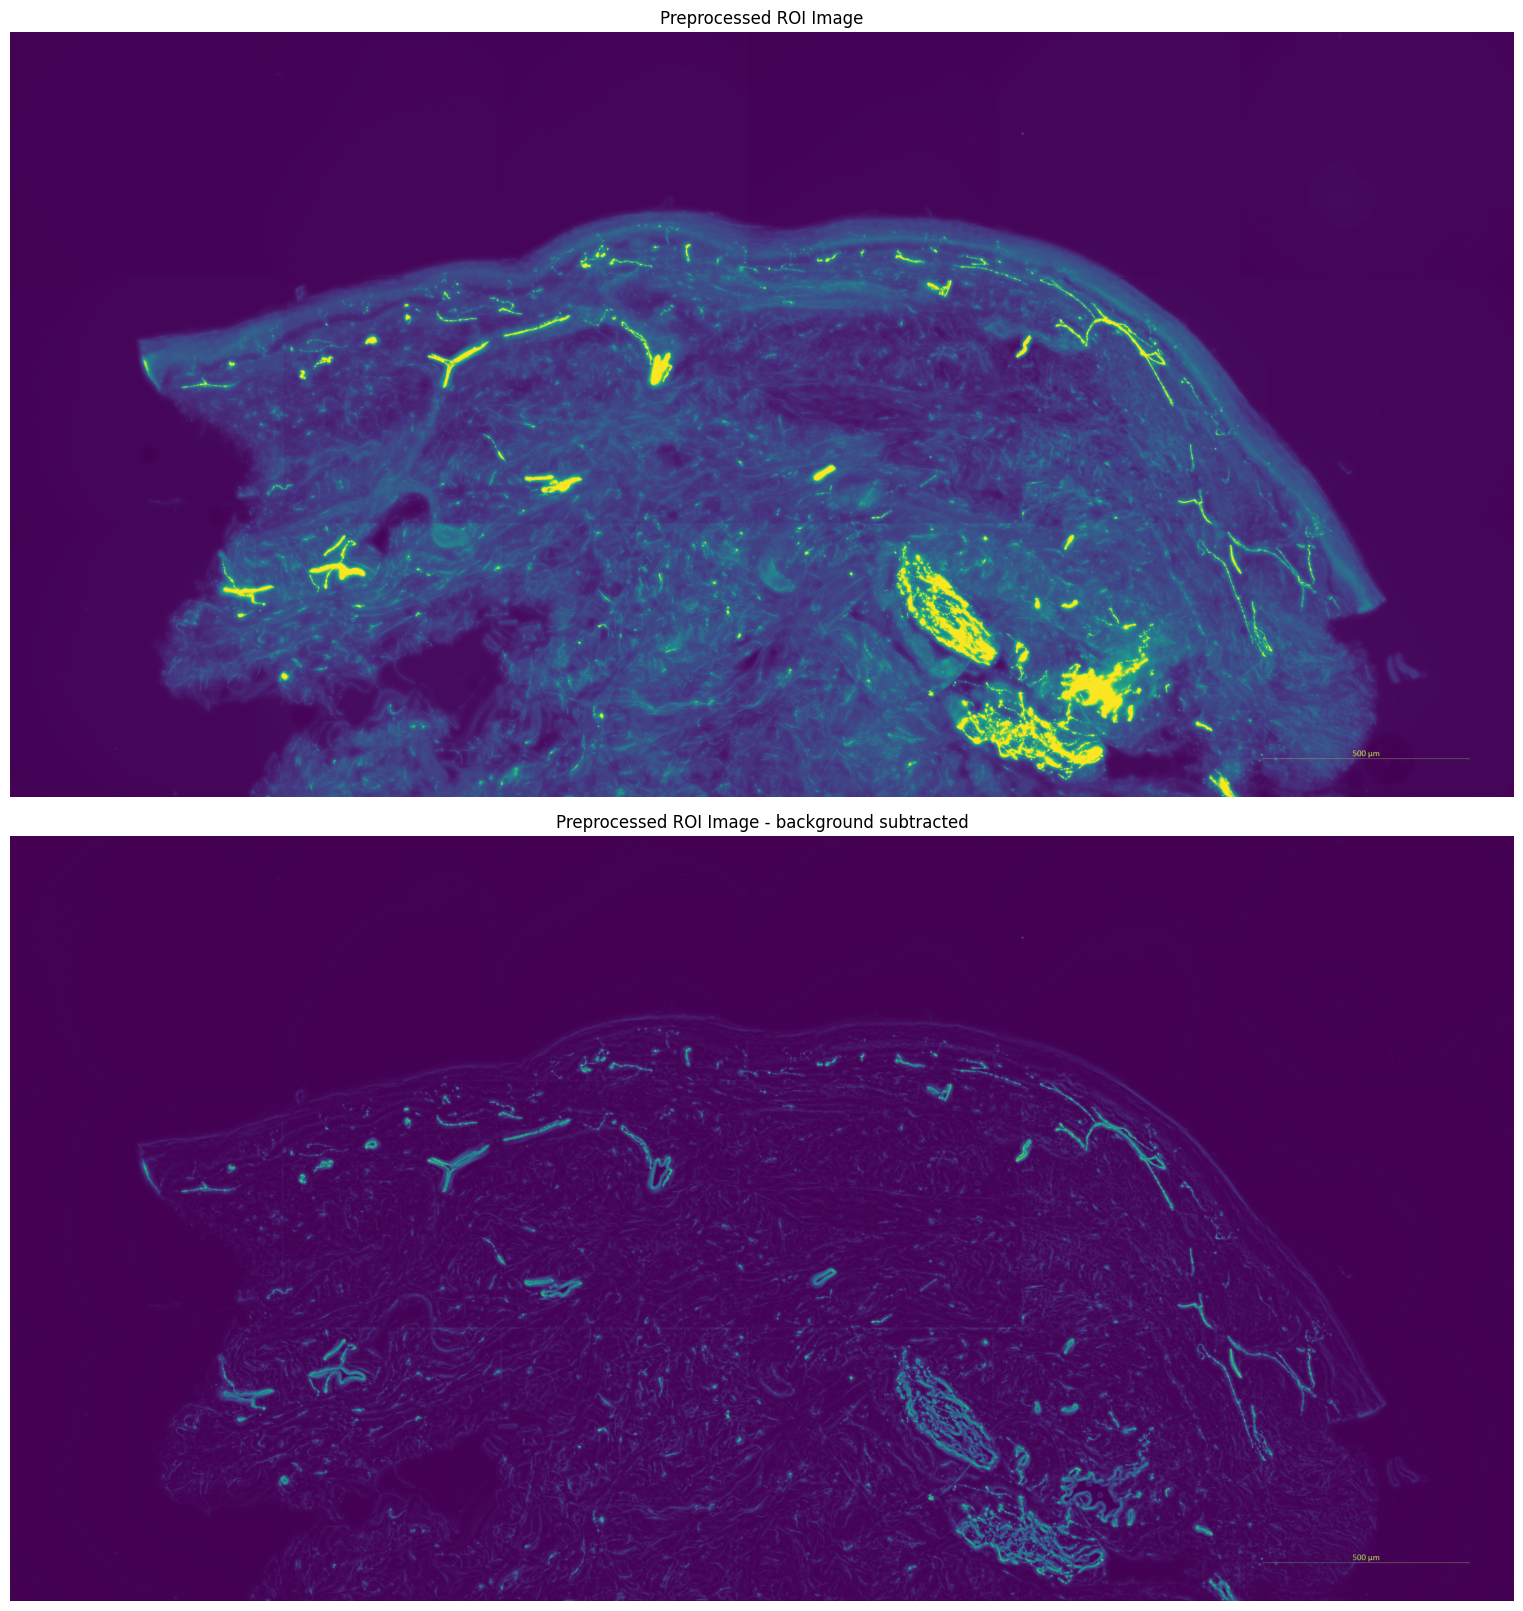

In [33]:
# Rolling ball background subtraction
sato_weight = 0


_, axes = plt.subplots(nrows=2, ncols=1, figsize=(32, 16), constrained_layout=True)

image_size = orig_img.shape
y_indices, x_indices = np.where(roi_mask > 0)
padding = 0
roi_y_start = max(np.min(y_indices) - padding, 0)
roi_y_end   = min(np.max(y_indices) + padding, image_size[0])
roi_x_start = max(np.min(x_indices) - padding, 0)
roi_x_end   = min(np.max(x_indices) + padding, image_size[1])

print(f"ROI height: {roi_y_end - roi_y_start}, width: {roi_x_end - roi_x_start}, y_start: {roi_y_start}, x_start: {roi_x_start}")

axes[0].imshow(orig_img)
axes[0].set_title('Preprocessed ROI Image')
axes[0].set_axis_off()

   
# Calculate fine background (minimum of two radii)
bg_small = ski.restoration.rolling_ball(orig_img, radius=10)
bg_tiny = ski.restoration.rolling_ball(orig_img, radius=2)
bg = np.minimum(bg_small, bg_tiny)

rolling_fg = (orig_img.astype(np.uint8) - bg.astype(np.uint8)).astype(np.uint8)

sato_result = sato(
    rolling_fg.astype(np.float32),
    sigmas=range(1, 3),      # 嘗試不同尺度
    black_ridges=False,      # 偵測亮的結構
    mode='reflect'
)

# 正規化到 0-255
sato_normalized = (sato_result - sato_result.min()) / (sato_result.max() - sato_result.min())
fg_img = (1-sato_weight) * rolling_fg + sato_weight * sato_normalized 
fg_img = fg_img.clip(0, 255).astype(np.uint8)

axes[1].imshow(fg_img)
axes[1].set_title('Preprocessed ROI Image - background subtracted')
axes[1].set_axis_off()
plt.show()

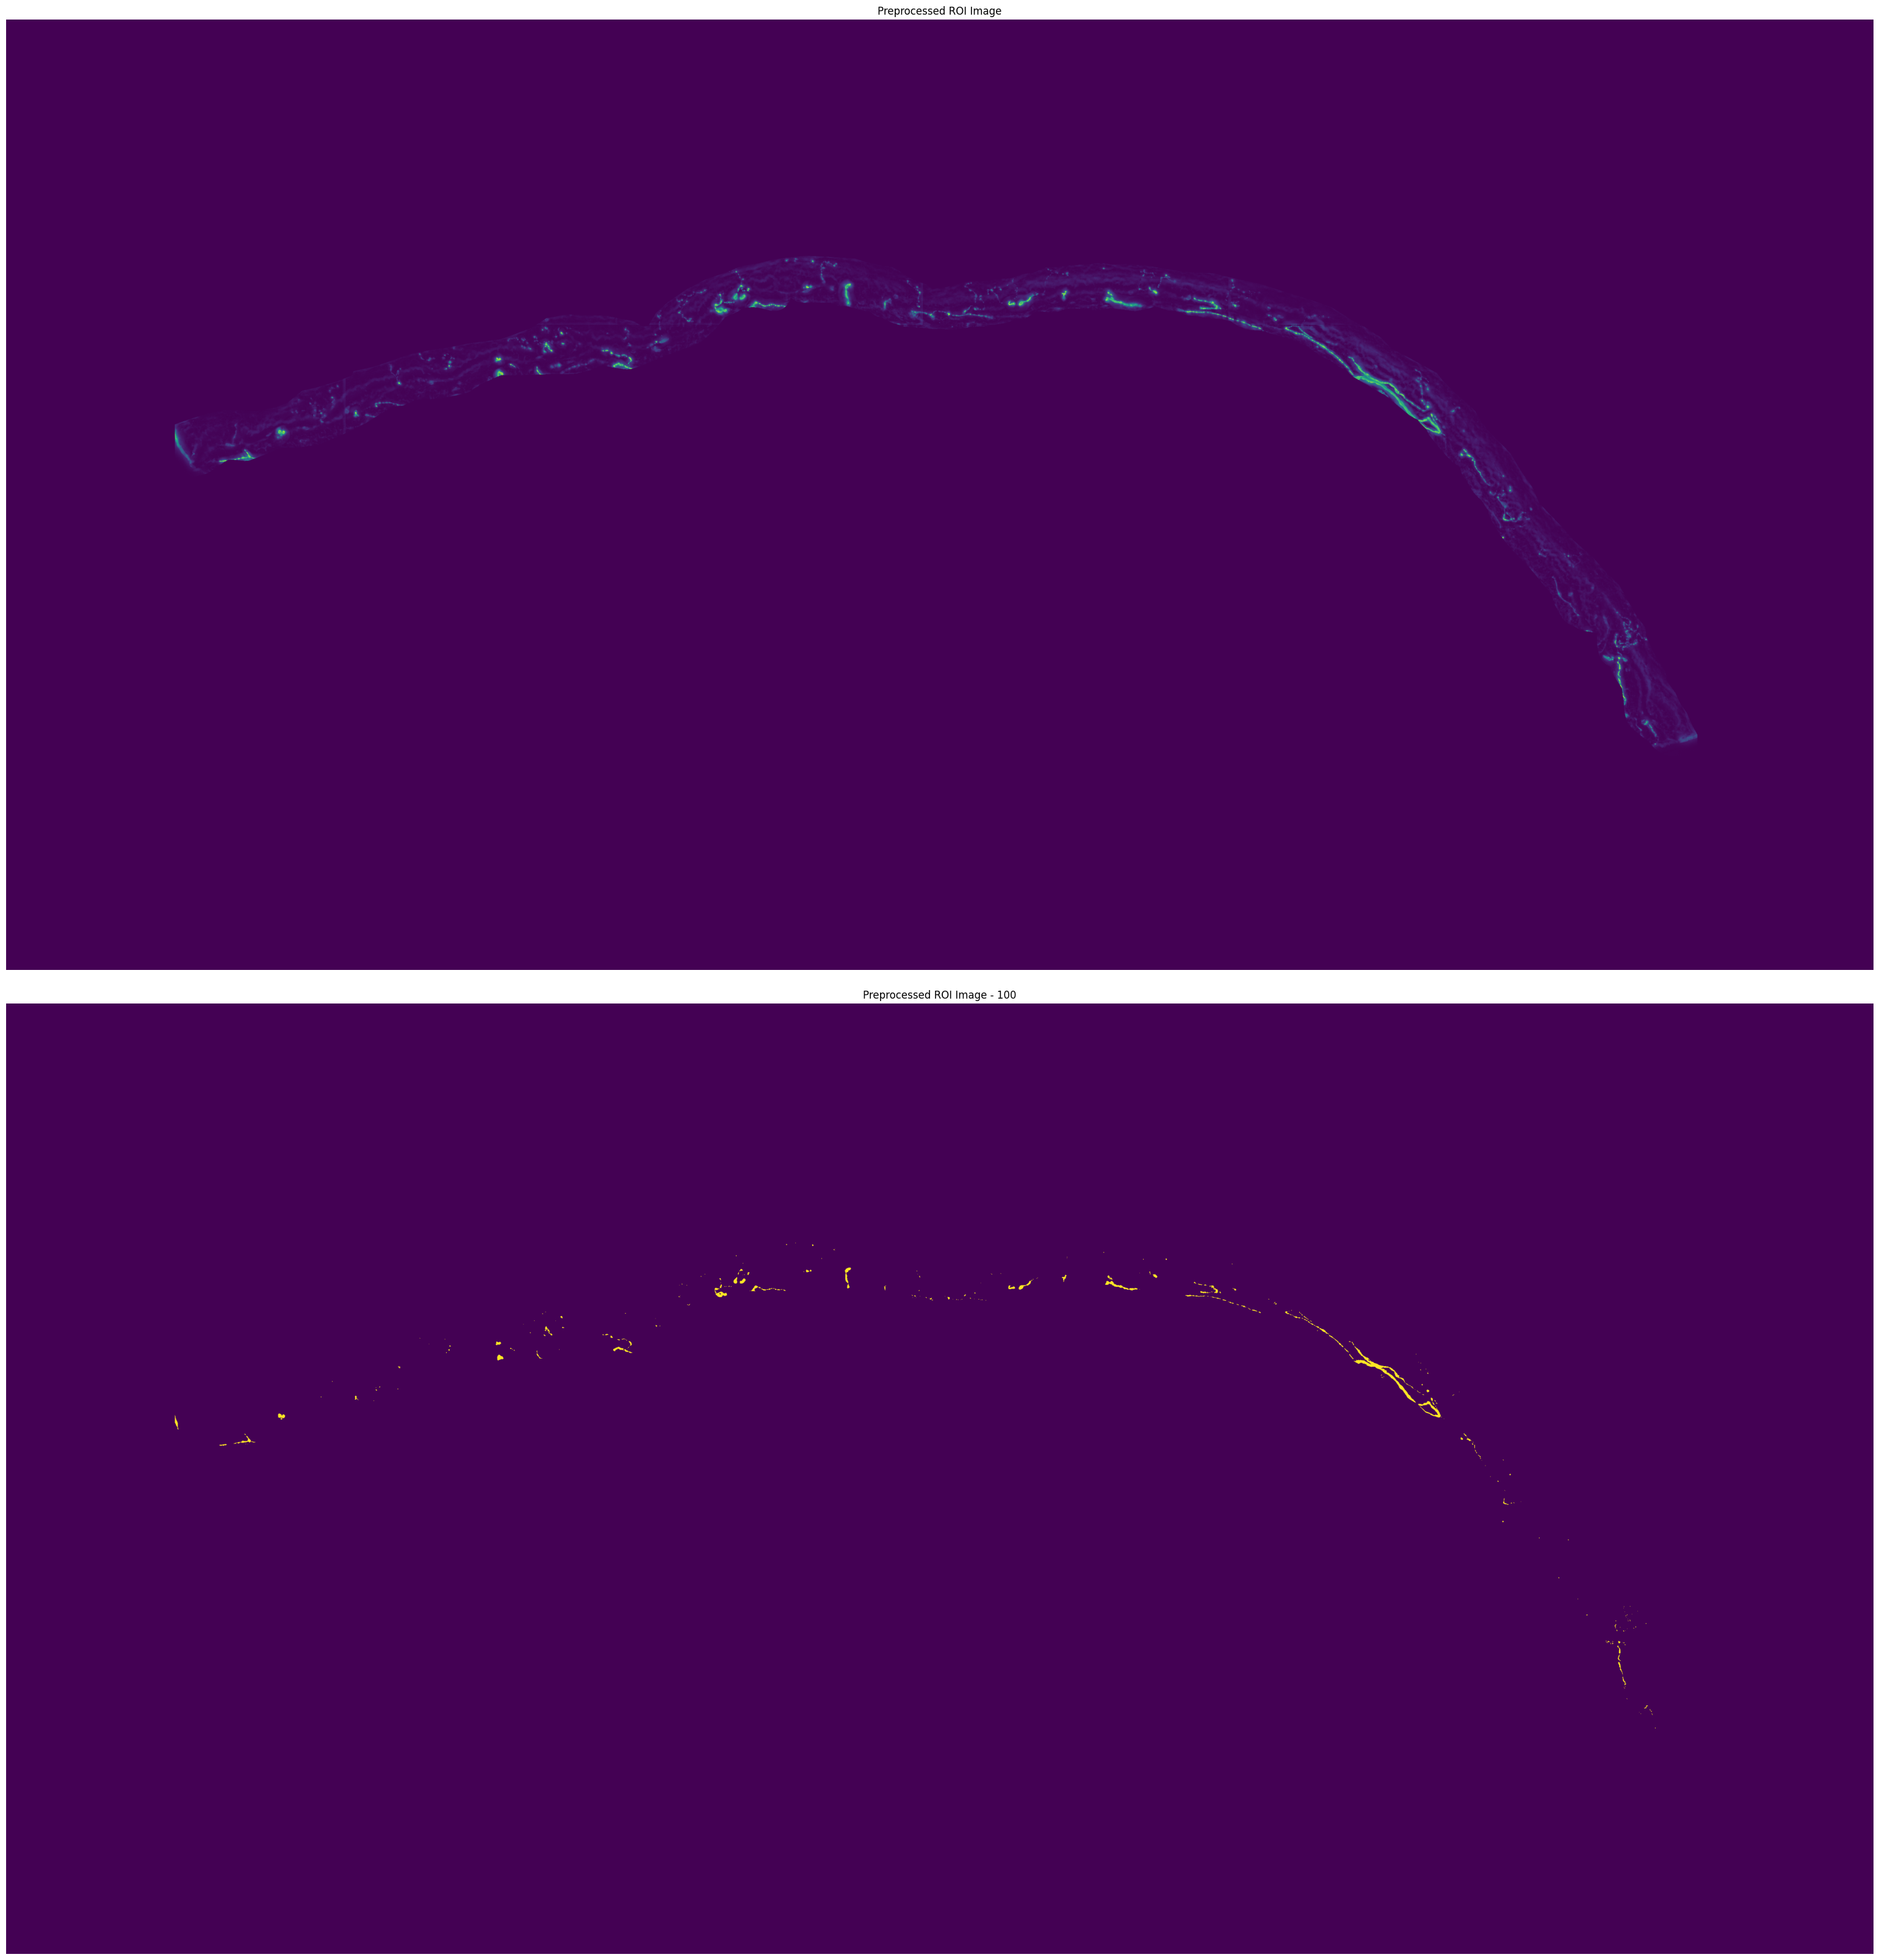

In [34]:
roi_image = cv2.bitwise_and(fg_img, fg_img, mask=roi_mask)

_, axes = plt.subplots(nrows=2, ncols=1, figsize=(32, 32), constrained_layout=True)
axes[0].imshow(roi_image)
axes[0].set_title('Preprocessed ROI Image')
axes[0].set_axis_off()

thresholds = ski.filters.threshold_multiotsu(roi_image)
regions = np.digitize(roi_image, bins=thresholds)

toplevel_mask = (regions == len(thresholds)).astype(np.uint8)

cv = ski.segmentation.chan_vese(
    roi_image.astype(np.float32),
    mu=0,
    lambda1=10,
    lambda2=1,
    tol=1e-4,
    max_num_iter=100,
    dt=0.5,
    init_level_set=toplevel_mask.astype(np.float32),
    extended_output=True,
)

axes[1].imshow(cv[0])
axes[1].set_title(f"Preprocessed ROI Image - {len(cv[2])}")
axes[1].set_axis_off()

plt.show() 

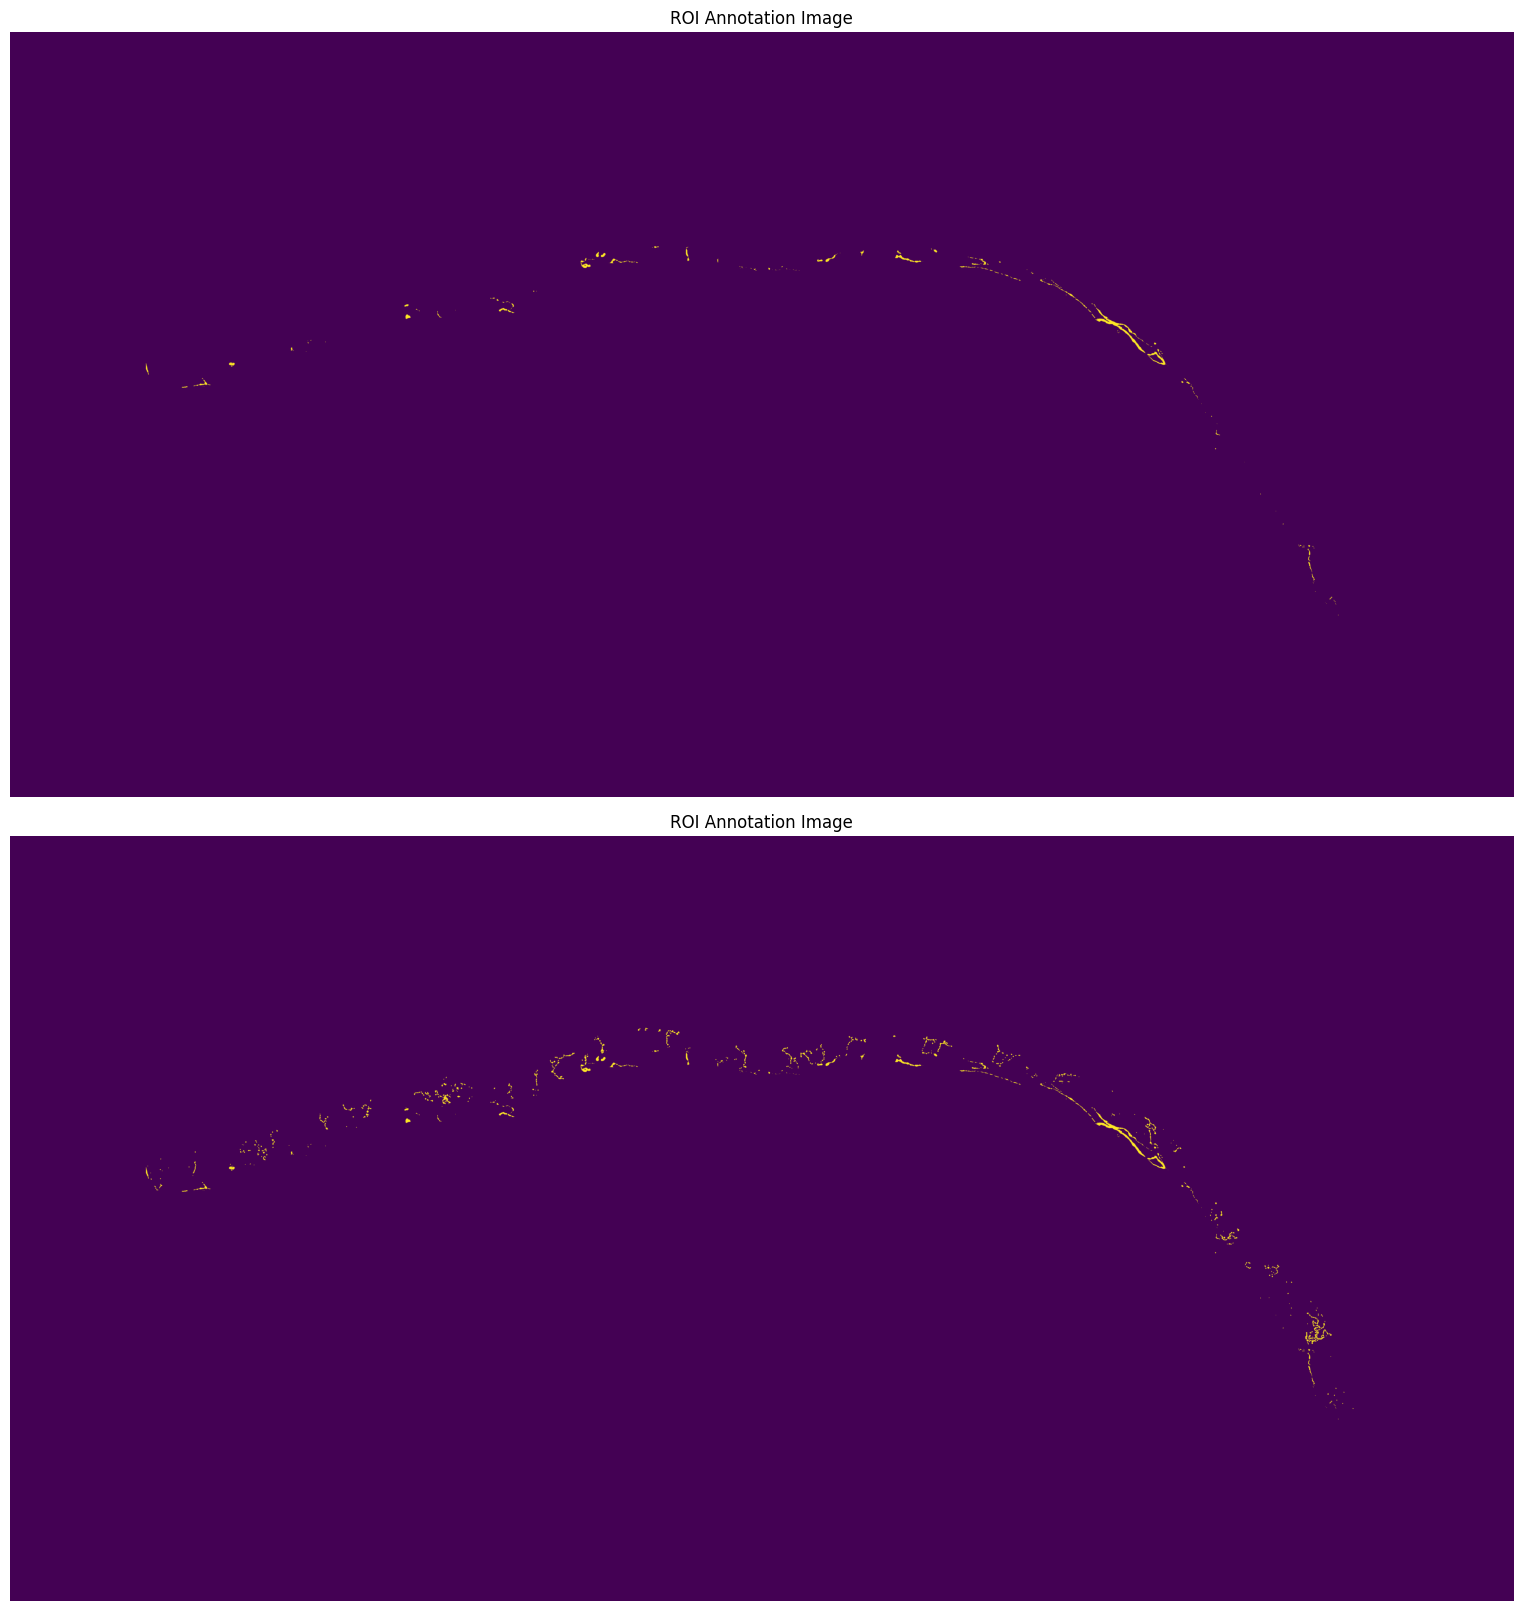

In [35]:
chanvese_mask = (cv[0] > 0).astype(np.uint8)

dermis_annotation = cv2.bitwise_and(chanvese_mask,chanvese_mask, mask=dermis_mask)

roi_annotation = cv2.bitwise_or(dermis_annotation, (annotation_img>0).astype(np.uint8))

_, axes = plt.subplots(nrows=2, ncols=1, figsize=(16, 16), constrained_layout=True)
axes[0].imshow(dermis_annotation)
axes[0].set_title('ROI Annotation Image')
axes[0].set_axis_off()


axes[1].imshow(roi_annotation)
axes[1].set_title('ROI Annotation Image')
axes[1].set_axis_off()

plt.show()

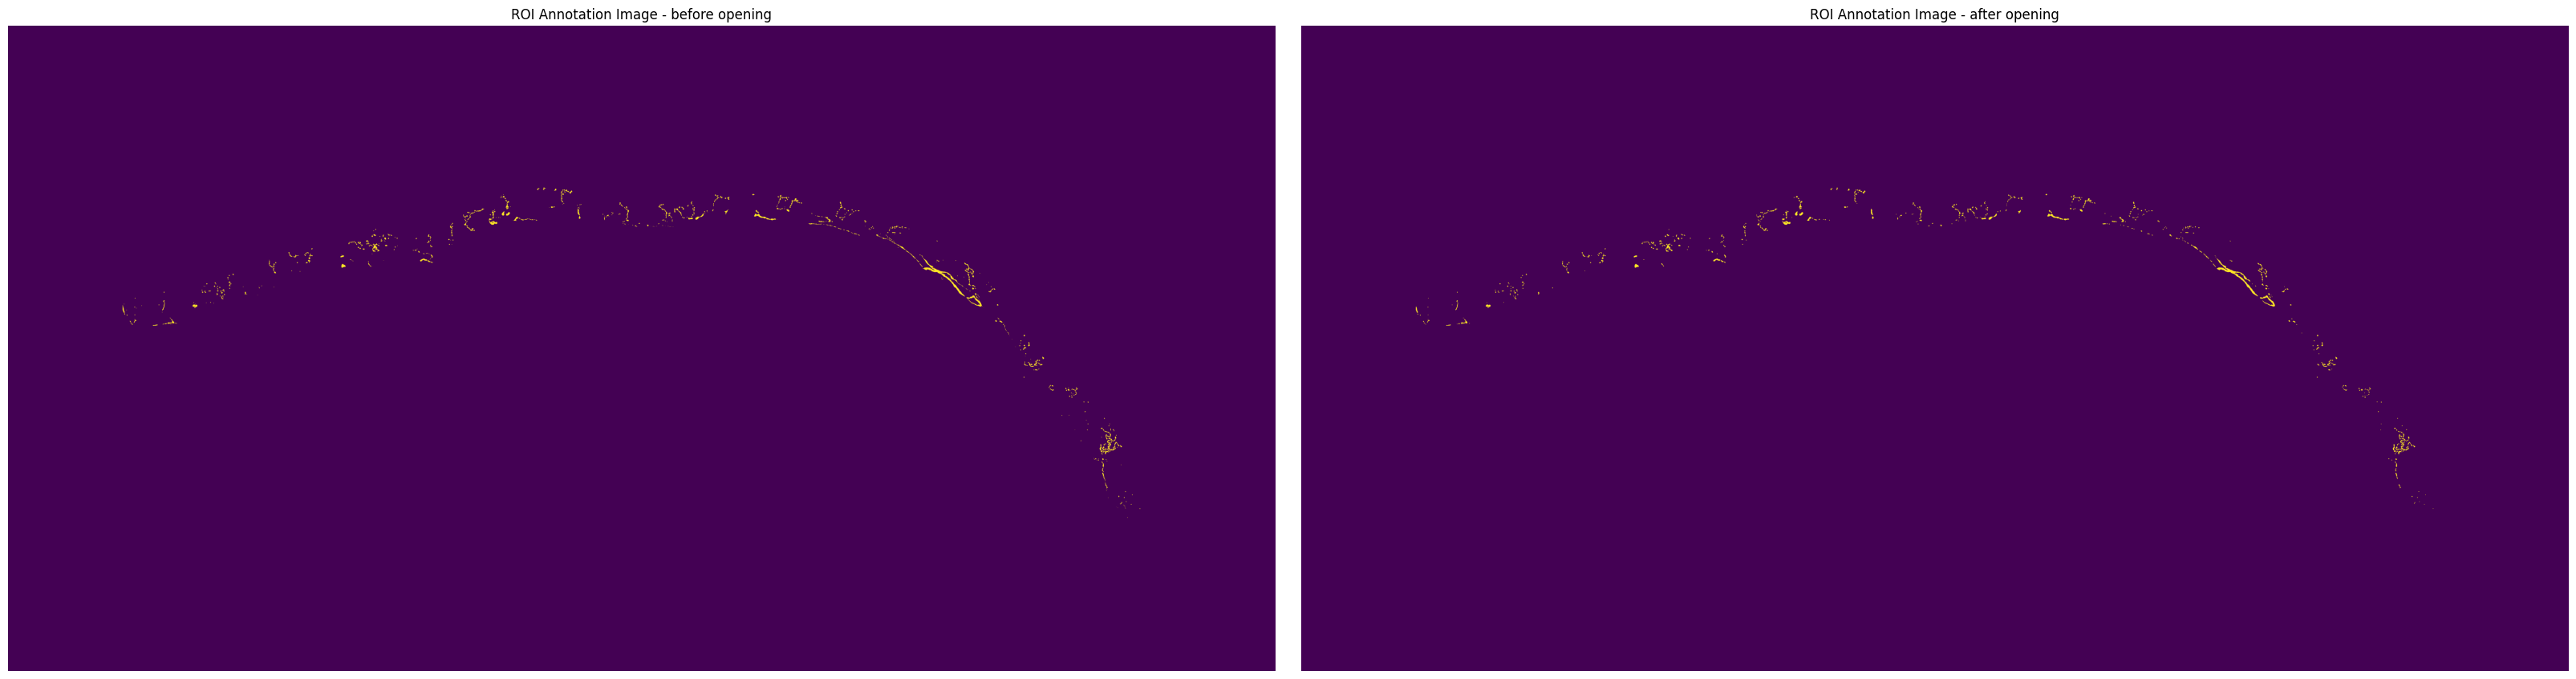

In [36]:
opening_roi_annotation = cv2.morphologyEx(roi_annotation.astype(np.uint8), cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3)), iterations=1)

_, axes = plt.subplots(nrows=1, ncols=2, figsize=(32, 16), constrained_layout=True)
axes[0].imshow(roi_annotation)
axes[0].set_title('ROI Annotation Image - before opening')
axes[0].set_axis_off()
axes[1].imshow(opening_roi_annotation)
axes[1].set_title('ROI Annotation Image - after opening')
axes[1].set_axis_off()
plt.show()

In [37]:
cv2.imwrite(f"{base_path}/roi_annotation.png", (roi_annotation * 255).astype(np.uint8))
cv2.imwrite(f"{base_path}/roi_image.png", roi_image.astype(np.uint8))

True